# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019) 

In [130]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [131]:
# 데이터셋 로드
DATA_DIR = os.path.expanduser(
    '/Users/jiwon/Desktop/jiwonvs/Mini-Project/ess-battery-project/batchdata'
)
# Batch 1 로드
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


In [132]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [133]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [134]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


In [135]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [136]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [137]:
df=pd.read_csv("/Users/jiwon/Desktop/jiwonvs/Mini-Project/ess-battery-project/dataset/batch1.csv")
df

,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442
...,...,...,...,...,...,...,...,...,...,...,...
38806,45,594,599,8C(35%)-3.6C,0.885883,0.887369,0.020337,38.676792,33.709809,30.059217,19.923232
38807,45,595,599,8C(35%)-3.6C,0.884301,0.885484,0.020473,38.678028,33.727794,30.237862,20.731932
38808,45,596,599,8C(35%)-3.6C,0.883173,0.884648,0.020493,38.663055,33.630904,30.104025,22.061037
38809,45,597,599,8C(35%)-3.6C,0.882425,0.883895,0.020503,38.717087,33.715893,30.051764,22.810185


In [138]:
# 결측치 처리
import numpy as np
import pandas as pd

df= df.sort_values(['cell_id', 'cycle']).copy()

# 앞/뒤 QD
prev_qd = df.groupby('cell_id')['QD'].transform(lambda s: s.shift(1))
next_qd = df.groupby('cell_id')['QD'].transform(lambda s: s.shift(-1))

# 앞뒤 평균
neighbor_avg = (prev_qd + next_qd) / 2

# 앞뒤 값끼리 차이: 작을수록 앞뒤가 비슷함
neighbor_gap = (next_qd - prev_qd).abs()

# 현재값이 앞뒤 평균에서 얼마나 튀는지
spike_diff = (df['QD'] - neighbor_avg).abs()

# 조건:
# 1) 앞뒤 값이 존재
# 2) 앞뒤 값은 서로 비슷
# 3) 현재 값만 유독 튐
spike_mask = (
    prev_qd.notna() &
    next_qd.notna() &
    (neighbor_gap < 0.02) &
    (spike_diff > 0.02)
)

# 이상치만 앞뒤 평균으로 치환
df.loc[spike_mask, 'QD'] = neighbor_avg[spike_mask]
# 사이클 1은 초기화 과정이므로 제외
df=df.loc[df['cycle']>1]

print("원본 shape:", df.shape)
print("보정 후 shape:", df.shape)
print("컬럼:", df.columns.tolist())

원본 shape: (38765, 11)
보정 후 shape: (38765, 11)
컬럼: ['cell_id', 'cycle', 'cycle_life', 'charging_policy', 'QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']


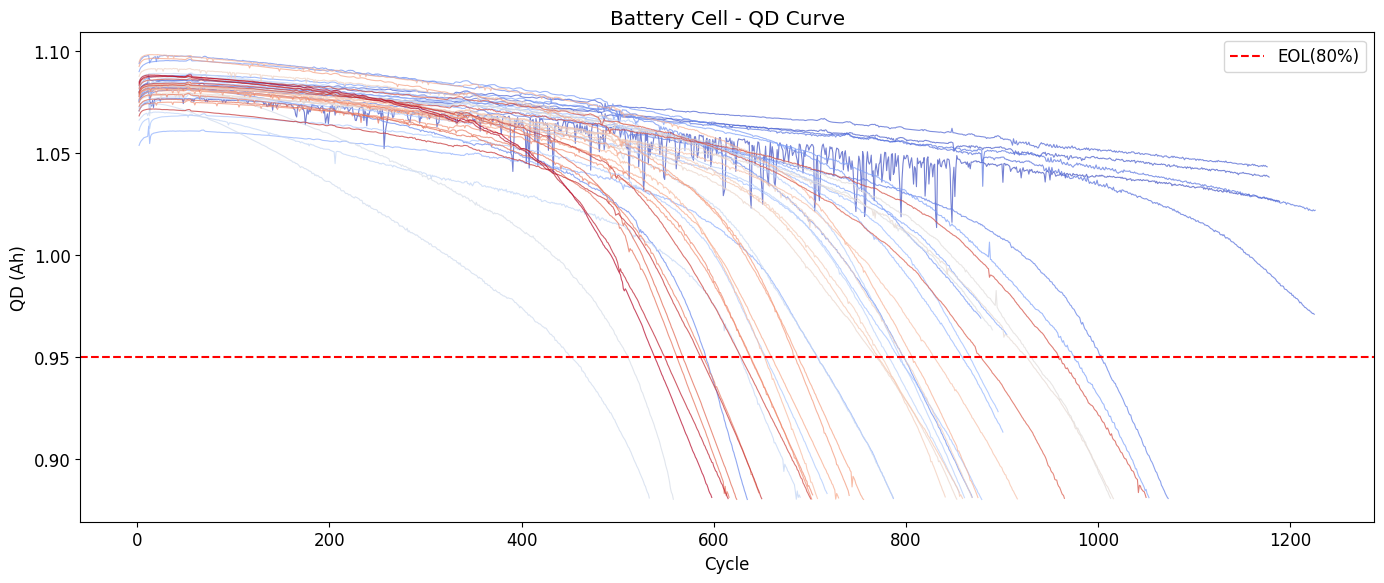

In [139]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Engineering

In [140]:
import numpy as np
import pandas as pd

df = df.sort_values(["cell_id", "cycle"]).copy()

############################################
# 기본 feature: 초기 100 cycle 통계
# 사용 컬럼: QD, IR, Tavg
############################################
df_100 = df[df["cycle"] <= 100].copy()

basic_feature_df = (
    df_100.groupby("cell_id")
    .agg(
        QD_mean=("QD", "mean"),
        QD_std=("QD", "std"),
        IR_mean=("IR", "mean"),
        IR_std=("IR", "std"),
        Tavg_mean=("Tavg", "mean"),
        Tavg_std=("Tavg", "std"),
    )
    .reset_index()
)

############################################
# charging policy 기반 feature
############################################
policy_feature_df = (
    df.drop_duplicates("cell_id")[["cell_id", "charging_policy"]]
    .copy()
)

policy_feature_df["C_rate_1"] = (
    policy_feature_df["charging_policy"]
    .str.extract(r"(\d+\.?\d*)C")[0]
    .astype(float)
)

policy_feature_df["ratio"] = (
    policy_feature_df["charging_policy"]
    .str.extract(r"\((\d+)%\)")[0]
    .astype(float)
)

policy_feature_df["C_rate_2"] = (
    policy_feature_df["charging_policy"]
    .str.extract(r"-([0-9\.]+)C")[0]
    .astype(float)
)

policy_feature_df["effective_C"] = (
    policy_feature_df["C_rate_1"] * policy_feature_df["ratio"] / 100.0
)

policy_feature_df = policy_feature_df[[
    "cell_id",
    "C_rate_1",
    "ratio",
    "C_rate_2",
    "effective_C"
]]

In [141]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

############################################
# 1. slope 파생 feature
############################################
def calc_slope(data, start_cycle, end_cycle):
    d = data[(data["cycle"] >= start_cycle) & (data["cycle"] <= end_cycle)].copy()
    d = d.dropna(subset=["cycle", "QD"])

    if len(d) < 2:
        return np.nan

    x = d["cycle"].values
    y = d["QD"].values

    return np.polyfit(x, y, 1)[0]

def get_slope_features(cell_df):
    cell_df = cell_df.sort_values("cycle")

    return pd.Series({
        "slope_early": calc_slope(cell_df, 1, 100),
        "slope_mid": calc_slope(cell_df, 101, 300),
        "slope_late": calc_slope(cell_df, 301, 600),
    })

slope_feature_df = (
    df.groupby("cell_id")
      .apply(get_slope_features)
      .reset_index()
)

slope_feature_df["slope_diff"] = slope_feature_df["slope_late"] - slope_feature_df["slope_early"]

############################################
# 2. 통계 기반 파생 feature
############################################
derived_stat_df = basic_feature_df.copy()

derived_stat_df["QD_cv"] = derived_stat_df["QD_std"] / derived_stat_df["QD_mean"]
derived_stat_df["IR_cv"] = derived_stat_df["IR_std"] / derived_stat_df["IR_mean"]
derived_stat_df["temp_ir_interaction"] = derived_stat_df["Tavg_mean"] * derived_stat_df["IR_mean"]

derived_stat_df = derived_stat_df[[
    "cell_id",
    "QD_cv",
    "IR_cv",
    "temp_ir_interaction"
]]

############################################
# 3. ΔQ(V) 파생 feature
############################################
cycle_life_df = df.groupby("cell_id", as_index=False)["cycle_life"].max()

def get_cycles_list(cell):
    cycles_list = cell["cycles"]
    if isinstance(cycles_list, dict):
        keys = list(cycles_list.keys())
        n = len(cycles_list[keys[0]])
        cycles_list = [{k: cycles_list[k][i] for k in keys} for i in range(n)]
    return cycles_list

def get_delta_qv(cell, cycle_a=10, cycle_b=100):
    cycles_list = get_cycles_list(cell)

    if len(cycles_list) < cycle_b:
        return None, None

    ca = cycles_list[cycle_a - 1]
    cb = cycles_list[cycle_b - 1]

    q_a = np.array(ca["Qdlin"]).flatten()
    q_b = np.array(cb["Qdlin"]).flatten()
    v = np.array(cell["Vdlin"]).flatten()

    min_len = min(len(v), len(q_a), len(q_b))
    if min_len == 0:
        return None, None

    v = v[:min_len]
    delta = q_b[:min_len] - q_a[:min_len]

    valid = np.isfinite(v) & np.isfinite(delta)
    v = v[valid]
    delta = delta[valid]

    if len(v) == 0:
        return None, None

    return v, delta

def get_delta_at_voltage(v, delta, target_v):
    idx = np.argmin(np.abs(v - target_v))
    return float(delta[idx])

delta_features = []

for cid in cycle_life_df["cell_id"]:
    v, delta = get_delta_qv(batch[cid], 10, 100)
    if v is None or len(delta) < 5:
        continue

    delta_mean = float(np.mean(delta))
    delta_std = float(np.std(delta))
    delta_var = float(np.var(delta))
    delta_min = float(np.min(delta))
    delta_max = float(np.max(delta))
    delta_range = float(delta_max - delta_min)
    delta_area = float(np.trapezoid(delta, v)) if hasattr(np, "trapezoid") else float(np.trapz(delta, v))
    delta_log_var = float(np.log10(delta_var + 1e-12))
    delta_skew = float(skew(delta, bias=False))
    delta_kurtosis = float(kurtosis(delta, bias=False, fisher=True))

    delta_v_2_0 = get_delta_at_voltage(v, delta, 2.0)
    delta_v_2_8 = get_delta_at_voltage(v, delta, 2.8)
    delta_v_3_0 = get_delta_at_voltage(v, delta, 3.0)

    mask_28_30 = (v >= 2.8) & (v <= 3.0)
    delta_28_30_mean = float(np.mean(delta[mask_28_30])) if np.any(mask_28_30) else np.nan

    delta_features.append({
        "cell_id": cid,
        "delta_mean": delta_mean,
        "delta_std": delta_std,
        "delta_var": delta_var,
        "delta_log_var": delta_log_var,
        "delta_min": delta_min,
        "delta_max": delta_max,
        "delta_range": delta_range,
        "delta_area": delta_area,
        "delta_skew": delta_skew,
        "delta_kurtosis": delta_kurtosis,
        "delta_v_2_0": delta_v_2_0,
        "delta_v_2_8": delta_v_2_8,
        "delta_v_3_0": delta_v_3_0,
        "delta_28_30_mean": delta_28_30_mean,
    })

delta_feature_df = pd.DataFrame(delta_features)

############################################
# 4. 파생 feature만 모으기
############################################
derived_feature_df = (
    slope_feature_df
    .merge(derived_stat_df, on="cell_id", how="left")
    .merge(delta_feature_df, on="cell_id", how="left")
)

In [142]:
############################################
# target: cycle_life
############################################
target_df = (
    df.groupby("cell_id", as_index=False)["cycle_life"]
      .max()
      .rename(columns={"cycle_life": "cycle_life"})
)

############################################
# 기본 feature + policy feature + 파생 feature + target 합치기
############################################
final_feature_df = (
    basic_feature_df
    .merge(policy_feature_df, on="cell_id", how="left")
    .merge(derived_feature_df, on="cell_id", how="left")
    .merge(target_df, on="cell_id", how="left")
)

############################################
# 사용할 feature 선택
############################################
selected_features = [
    # ΔQ 핵심
    "delta_log_var",

    # 초기 안정성
    "QD_cv",

    # 충전 조건
    "effective_C",

    # interaction
    "temp_ir_interaction" 
]

############################################
# 최종 feature / target 분리
############################################
X = final_feature_df[selected_features].copy()
y = final_feature_df["cycle_life"].copy()

display(final_feature_df[selected_features + ["cycle_life"]].head())

print("final_feature_df shape:", final_feature_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

############################################
# 사용 feature 확인
############################################
print("\n최종 사용 feature")
for f in selected_features:
    print("-", f)

,delta_log_var,QD_cv,effective_C,temp_ir_interaction,cycle_life
0,-5.014861,0.001125,2.88,0.525991,1190
1,-5.013960,0.001101,2.88,0.524809,1179
2,-4.737000,0.000945,2.88,0.522548,1177
3,-4.442613,0.001011,3.20,0.483451,1226
4,-4.647744,0.001011,3.20,0.518923,1227


final_feature_df shape: (46, 33)
X shape: (46, 4)
y shape: (46,)

최종 사용 feature
- delta_log_var
- QD_cv
- effective_C
- temp_ir_interaction


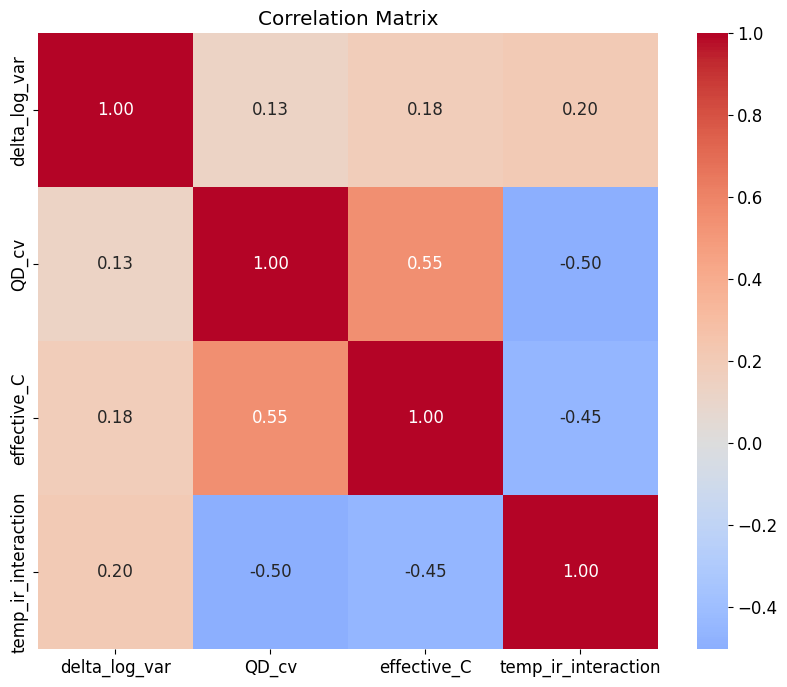

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

# 숫자형 변수만
corr = X.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,        # 숫자 표시
    fmt=".2f"          # 소수점 2자리
)
plt.title("Correlation Matrix")
plt.show()

## Batch 2 로드

In [144]:
# batch2 로드
batch2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch2_path)

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)


In [145]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 5_2C_58PER_4C
  policy_readable           | str      | 5.2C(58%)-4C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [146]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 496

사이클[0] 내 변수 목록 :
  I               | ndarray | shape=(1042,) | dtype=float64
  Qc              | ndarray | shape=(1042,) | dtype=float64
  Qd              | ndarray | shape=(1042,) | dtype=float64
  Qdlin           | ndarray | shape=(1000,) | dtype=float64
  T               | ndarray | shape=(1042,) | dtype=float64
  Tdlin           | ndarray | shape=(1000,) | dtype=float64
  V               | ndarray | shape=(1042,) | dtype=float64
  discharge_dQdV  | ndarray | shape=(1000,) | dtype=float64
  t               | ndarray | shape=(1042,) | dtype=float64


In [147]:
import numpy as np
import pandas as pd

def safe_scalar(x):
    # MATLAB scalar를 파이썬 scalar로 변환
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        if x.size == 1:
            return x.item()
    return x

def safe_int(x):
    # 결측이면 np.nan 반환, 아니면 int 변환
    x = safe_scalar(x)
    if x is None:
        return np.nan
    try:
        if pd.isna(x):
            return np.nan
        return int(x)
    except:
        return np.nan

def safe_str(x, default='unknown'):
    # 문자열 결측 처리
    x = safe_scalar(x)
    if x is None:
        return default
    try:
        if pd.isna(x):
            return default
    except:
        pass
    return str(x)

def extract_summary(batch):
    rows = []

    for i, cell in enumerate(batch):
        summary = cell.get('summary', {})
        if not isinstance(summary, dict):
            continue

        cycle = np.asarray(summary.get('cycle', []))
        qd    = np.asarray(summary.get('QDischarge', []))
        qc    = np.asarray(summary.get('QCharge', []))
        ir    = np.asarray(summary.get('IR', []))
        tavg  = np.asarray(summary.get('Tavg', []))
        tmax  = np.asarray(summary.get('Tmax', []))
        tmin  = np.asarray(summary.get('Tmin', []))
        ct    = np.asarray(summary.get('chargetime', []))

        cycle_life = safe_int(cell.get('cycle_life'))
        policy = safe_str(cell.get('policy_readable')) \
                 if cell.get('policy_readable') is not None \
                 else safe_str(cell.get('policy'))

        n = min(len(cycle), len(qd), len(qc), len(ir), len(tavg), len(tmax), len(tmin), len(ct))

        for j in range(n):
            rows.append({
                'cell_id': i,
                'cycle': cycle[j],
                'cycle_life': cycle_life,
                'QD': qd[j],
                'QC': qc[j],
                'IR': ir[j],
                'Tmax': tmax[j],
                'Tavg': tavg[j],
                'Tmin': tmin[j],
                'chargetime': ct[j],
                'charging_policy': policy
            })

    return pd.DataFrame(rows)

In [148]:
df2 = extract_summary(batch)
df2 = df2.sort_values(["cell_id", "cycle"]).copy()
df2=df2.dropna(subset=["cycle_life"])
print(f"DataFrame shape : {df2.shape}")

DataFrame shape : (23034, 11)


## Batch 2 전처리

In [149]:
df2

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime,charging_policy
0,0,1.0,477.0,1.100081,1.093134,0.017568,34.939963,31.711117,29.923351,10.173582,5.2C(58%)-4C
1,0,2.0,477.0,1.102005,1.095290,0.017403,34.932640,31.694268,29.485325,10.174120,5.2C(58%)-4C
2,0,3.0,477.0,1.102657,1.095671,0.017483,35.013324,31.562588,29.496650,10.173655,5.2C(58%)-4C
3,0,4.0,477.0,1.104077,1.096824,0.017495,34.874825,31.466974,29.558488,10.173165,5.2C(58%)-4C
4,0,5.0,477.0,1.103926,1.095358,0.017292,34.603157,31.418444,29.035449,10.174460,5.2C(58%)-4C
...,...,...,...,...,...,...,...,...,...,...,...
26899,46,519.0,503.0,0.836821,0.857202,0.000000,32.093512,30.747558,28.981575,20.000000,4.8C(80%)-4.8C
26900,46,520.0,503.0,0.832981,0.852149,0.000000,32.722466,31.027024,29.995840,20.000000,4.8C(80%)-4.8C
26901,46,521.0,503.0,0.833070,0.848191,0.000000,32.094832,30.842200,28.774714,20.000000,4.8C(80%)-4.8C
26902,46,522.0,503.0,0.830678,0.849550,0.000000,32.542927,30.991842,29.880506,20.000000,4.8C(80%)-4.8C


In [150]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

############################################
# 1. summary dataframe 생성
############################################
df2 = extract_summary(batch2)
df2=df2.dropna(subset=["cycle_life"]).copy()
print(f"DataFrame shape : {df2.shape}")

############################################
# 2. 정렬
############################################
df2 = df2.sort_values(["cell_id", "cycle"]).copy()

############################################
# 3. 초기 100 cycle 기본 통계 feature
############################################
df2_100 = df2[df2["cycle"] <= 100].copy()

basic_feature_df2 = (
    df2_100.groupby("cell_id", as_index=False)
    .agg(
        QD_mean=("QD", "mean"),
        QD_std=("QD", "std"),
        IR_mean=("IR", "mean"),
        IR_std=("IR", "std"),
        Tavg_mean=("Tavg", "mean"),
        Tavg_std=("Tavg", "std"),
    )
)

############################################
# 4. 통계 기반 파생 feature
############################################
basic_feature_df2["QD_cv"] = basic_feature_df2["QD_std"] / basic_feature_df2["QD_mean"]
basic_feature_df2["IR_cv"] = basic_feature_df2["IR_std"] / basic_feature_df2["IR_mean"]
basic_feature_df2["temp_ir_interaction"] = basic_feature_df2["Tavg_mean"] * basic_feature_df2["IR_mean"]

############################################
# 5. charging policy feature
############################################
policy_feature_df2 = (
    df2.drop_duplicates("cell_id")[["cell_id", "charging_policy"]]
    .copy()
)

policy_feature_df2["C_rate_1"] = (
    policy_feature_df2["charging_policy"]
    .str.extract(r"(\d+\.?\d*)C")[0]
    .astype(float)
)

policy_feature_df2["ratio"] = (
    policy_feature_df2["charging_policy"]
    .str.extract(r"\((\d+)%\)")[0]
    .astype(float)
)

policy_feature_df2["C_rate_2"] = (
    policy_feature_df2["charging_policy"]
    .str.extract(r"-([0-9\.]+)C")[0]
    .astype(float)
)

policy_feature_df2["effective_C"] = (
    policy_feature_df2["C_rate_1"] * policy_feature_df2["ratio"] / 100.0
)

############################################
# 6. slope feature
############################################
slope_feature_df2 = (
    df2.groupby("cell_id")
    .apply(get_slope_features)
    .reset_index()
)

slope_feature_df2["slope_diff"] = (
    slope_feature_df2["slope_late"] - slope_feature_df2["slope_early"]
)

############################################
# 7. delta feature
############################################
cycle_life_df2 = df2.groupby("cell_id", as_index=False)["cycle_life"].max()

delta_features2 = []

for cid in cycle_life_df2["cell_id"]:
    try:
        v, delta = get_delta_qv(batch2[cid], 10, 100)

        if v is None or len(delta) < 5:
            continue

        delta_mean = float(np.mean(delta))
        delta_std = float(np.std(delta))
        delta_var = float(np.var(delta))
        delta_min = float(np.min(delta))
        delta_max = float(np.max(delta))
        delta_range = float(delta_max - delta_min)
        delta_area = float(np.trapezoid(delta, v)) if hasattr(np, "trapezoid") else float(np.trapz(delta, v))
        delta_log_var = float(np.log10(delta_var + 1e-12))
        delta_skew = float(skew(delta, bias=False))
        delta_kurtosis = float(kurtosis(delta, bias=False, fisher=True))

        delta_v_2_0 = get_delta_at_voltage(v, delta, 2.0)
        delta_v_2_8 = get_delta_at_voltage(v, delta, 2.8)
        delta_v_3_0 = get_delta_at_voltage(v, delta, 3.0)

        mask_28_30 = (v >= 2.8) & (v <= 3.0)
        delta_28_30_mean = float(np.mean(delta[mask_28_30])) if np.any(mask_28_30) else np.nan

        delta_features2.append({
            "cell_id": cid,
            "delta_mean": delta_mean,
            "delta_std": delta_std,
            "delta_var": delta_var,
            "delta_log_var": delta_log_var,
            "delta_min": delta_min,
            "delta_max": delta_max,
            "delta_range": delta_range,
            "delta_area": delta_area,
            "delta_skew": delta_skew,
            "delta_kurtosis": delta_kurtosis,
            "delta_v_2_0": delta_v_2_0,
            "delta_v_2_8": delta_v_2_8,
            "delta_v_3_0": delta_v_3_0,
            "delta_28_30_mean": delta_28_30_mean,
        })

    except Exception as e:
        print(f"cell_id {cid} delta error: {e}")

delta_feature_df2 = pd.DataFrame(
    delta_features2,
    columns=[
        "cell_id",
        "delta_mean", "delta_std", "delta_var", "delta_log_var",
        "delta_min", "delta_max", "delta_range", "delta_area",
        "delta_skew", "delta_kurtosis",
        "delta_v_2_0", "delta_v_2_8", "delta_v_3_0",
        "delta_28_30_mean"
    ]
)

############################################
# 8. target
############################################
target_df2 = (
    df2.groupby("cell_id", as_index=False)["cycle_life"]
    .max()
)

############################################
# 9. 최종 feature dataframe
############################################
final_feature_df2 = (
    basic_feature_df2
    .merge(
        policy_feature_df2[
            ["cell_id", "C_rate_1", "ratio", "C_rate_2", "effective_C"]
        ],
        on="cell_id",
        how="left"
    )
    .merge(
        slope_feature_df2[
            ["cell_id", "slope_early", "slope_mid", "slope_late", "slope_diff"]
        ],
        on="cell_id",
        how="left"
    )
    .merge(
        delta_feature_df2,
        on="cell_id",
        how="left"
    )
    .merge(
        target_df2.rename(columns={"cycle_life": "cycle_life"}),
        on="cell_id",
        how="left"
    )
)

############################################
# 10. 모델 입력용 valid set
############################################
selected_features = [
    "delta_log_var",
    "QD_cv",
    "effective_C",
    "temp_ir_interaction"
]

X_test = final_feature_df2[selected_features].copy()
y_test = final_feature_df2["cycle_life"].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
display(X_test.head())

DataFrame shape : (23034, 11)
X_test shape: (39, 4)
y_test shape: (39,)


,delta_log_var,QD_cv,effective_C,temp_ir_interaction
0,-3.487265,0.002837,3.0160,0.551483
1,-3.298051,0.003101,1.4560,0.589958
2,-3.460248,0.010456,2.6000,0.546216
3,-3.496243,0.002792,2.0460,0.540214
4,-3.232507,0.002975,3.2085,0.535276


## Batch 3

In [164]:
# batch3 로드
batch3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch3_path)

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)


In [178]:
batch3 = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch3, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch3.keys())
    n_cells = len(batch3[keys[0]])
    batch3 = [{k: batch3[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

# 단일 셀 구조 상세 확인
cell0 = batch3[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 5C_67PER_4C_NEWSTRUCTURE
  policy_readable           | str      | 5C(67%)-4C-newstructure
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [179]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1008

사이클[0] 내 변수 목록 :
  I               | ndarray | shape=(762,) | dtype=float64
  Qc              | ndarray | shape=(762,) | dtype=float64
  Qd              | ndarray | shape=(762,) | dtype=float64
  Qdlin           | ndarray | shape=(1000,) | dtype=float64
  T               | ndarray | shape=(762,) | dtype=float64
  Tdlin           | ndarray | shape=(1000,) | dtype=float64
  V               | ndarray | shape=(762,) | dtype=float64
  discharge_dQdV  | ndarray | shape=(1000,) | dtype=float64
  t               | ndarray | shape=(762,) | dtype=float64


In [180]:
import numpy as np
import pandas as pd

def safe_scalar(x):
    # MATLAB scalar를 파이썬 scalar로 변환
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        if x.size == 1:
            return x.item()
    return x

def safe_int(x):
    # 결측이면 np.nan 반환, 아니면 int 변환
    x = safe_scalar(x)
    if x is None:
        return np.nan
    try:
        if pd.isna(x):
            return np.nan
        return int(x)
    except:
        return np.nan

def safe_str(x, default='unknown'):
    # 문자열 결측 처리
    x = safe_scalar(x)
    if x is None:
        return default
    try:
        if pd.isna(x):
            return default
    except:
        pass
    return str(x)

def extract_summary(batch3):
    rows = []

    for i, cell in enumerate(batch3):
        summary = cell.get('summary', {})
        if not isinstance(summary, dict):
            continue

        cycle = np.asarray(summary.get('cycle', []))
        qd    = np.asarray(summary.get('QDischarge', []))
        qc    = np.asarray(summary.get('QCharge', []))
        ir    = np.asarray(summary.get('IR', []))
        tavg  = np.asarray(summary.get('Tavg', []))
        tmax  = np.asarray(summary.get('Tmax', []))
        tmin  = np.asarray(summary.get('Tmin', []))
        ct    = np.asarray(summary.get('chargetime', []))

        cycle_life = safe_int(cell.get('cycle_life'))
        policy = safe_str(cell.get('policy_readable')) \
                 if cell.get('policy_readable') is not None \
                 else safe_str(cell.get('policy'))

        n = min(len(cycle), len(qd), len(qc), len(ir), len(tavg), len(tmax), len(tmin), len(ct))

        for j in range(n):
            rows.append({
                'cell_id': i,
                'cycle': cycle[j],
                'cycle_life': cycle_life,
                'QD': qd[j],
                'QC': qc[j],
                'IR': ir[j],
                'Tmax': tmax[j],
                'Tavg': tavg[j],
                'Tmin': tmin[j],
                'chargetime': ct[j],
                'charging_policy': policy
            })

    return pd.DataFrame(rows)

In [181]:
df3 = extract_summary(batch3)
df3 = df3.sort_values(["cell_id", "cycle"]).copy()
df3=df3.dropna(subset=["cycle_life"])
print(f"DataFrame shape : {df3.shape}")

DataFrame shape : (46581, 11)


## Batch 2 전처리

In [182]:
df3

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime,charging_policy
0,0,1.0,1009.0,1.066573,1.066090,0.015435,33.433834,32.149495,30.830272,10.043408,5C(67%)-4C-newstructure
1,0,2.0,1009.0,1.067455,1.066964,0.015399,33.403964,32.106606,30.779943,10.043255,5C(67%)-4C-newstructure
2,0,3.0,1009.0,1.068285,1.067611,0.015365,33.325268,32.088511,30.824746,10.042333,5C(67%)-4C-newstructure
3,0,4.0,1009.0,1.068708,1.068164,0.015326,33.304202,32.086306,30.804544,10.052677,5C(67%)-4C-newstructure
4,0,5.0,1009.0,1.069094,1.068695,0.015309,33.257191,32.041147,30.791834,10.042382,5C(67%)-4C-newstructure
...,...,...,...,...,...,...,...,...,...,...,...
51002,45,1796.0,1801.0,0.881539,0.881796,0.017538,34.571934,32.532753,30.328932,15.404138,4.8C(80%)-4.8C-newstructure
51003,45,1797.0,1801.0,0.881441,0.881874,0.017294,35.492989,32.679857,29.591684,15.497987,4.8C(80%)-4.8C-newstructure
51004,45,1798.0,1801.0,0.880883,0.881364,0.017605,33.999550,32.217071,31.470758,16.357937,4.8C(80%)-4.8C-newstructure
51005,45,1799.0,1801.0,0.880757,0.881120,0.017526,35.779078,33.035630,29.526152,16.046140,4.8C(80%)-4.8C-newstructure


In [183]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

############################################
# 1. summary dataframe 생성
############################################
df3 = extract_summary(batch3)
df3=df3.dropna(subset=["cycle_life"]).copy()
print(f"DataFrame shape : {df3.shape}")

############################################
# 2. 정렬
############################################
df3 = df3.sort_values(["cell_id", "cycle"]).copy()

############################################
# 3. 초기 100 cycle 기본 통계 feature
############################################
df3_100 = df3[df3["cycle"] <= 100].copy()

basic_feature_df3 = (
    df3_100.groupby("cell_id", as_index=False)
    .agg(
        QD_mean=("QD", "mean"),
        QD_std=("QD", "std"),
        IR_mean=("IR", "mean"),
        IR_std=("IR", "std"),
        Tavg_mean=("Tavg", "mean"),
        Tavg_std=("Tavg", "std"),
    )
)

############################################
# 4. 통계 기반 파생 feature
############################################
basic_feature_df3["QD_cv"] = basic_feature_df3["QD_std"] / basic_feature_df3["QD_mean"]
basic_feature_df3["IR_cv"] = basic_feature_df3["IR_std"] / basic_feature_df3["IR_mean"]
basic_feature_df3["temp_ir_interaction"] = basic_feature_df3["Tavg_mean"] * basic_feature_df3["IR_mean"]

############################################
# 5. charging policy feature
############################################
policy_feature_df3 = (
    df3.drop_duplicates("cell_id")[["cell_id", "charging_policy"]]
    .copy()
)

policy_feature_df3["C_rate_1"] = (
    policy_feature_df3["charging_policy"]
    .str.extract(r"(\d+\.?\d*)C")[0]
    .astype(float)
)

policy_feature_df3["ratio"] = (
    policy_feature_df3["charging_policy"]
    .str.extract(r"\((\d+)%\)")[0]
    .astype(float)
)

policy_feature_df3["C_rate_2"] = (
    policy_feature_df3["charging_policy"]
    .str.extract(r"-([0-9\.]+)C")[0]
    .astype(float)
)

policy_feature_df3["effective_C"] = (
    policy_feature_df3["C_rate_1"] * policy_feature_df3["ratio"] / 100.0
)

############################################
# 6. slope feature
############################################
slope_feature_df3 = (
    df3.groupby("cell_id")
    .apply(get_slope_features)
    .reset_index()
)

slope_feature_df3["slope_diff"] = (
    slope_feature_df3["slope_late"] - slope_feature_df3["slope_early"]
)

############################################
# 7. delta feature
############################################
cycle_life_df3 = df3.groupby("cell_id", as_index=False)["cycle_life"].max()

delta_features3 = []

for cid in cycle_life_df3["cell_id"]:
    try:
        v, delta = get_delta_qv(batch3[cid], 10, 100)

        if v is None or len(delta) < 5:
            continue

        delta_mean = float(np.mean(delta))
        delta_std = float(np.std(delta))
        delta_var = float(np.var(delta))
        delta_min = float(np.min(delta))
        delta_max = float(np.max(delta))
        delta_range = float(delta_max - delta_min)
        delta_area = float(np.trapezoid(delta, v)) if hasattr(np, "trapezoid") else float(np.trapz(delta, v))
        delta_log_var = float(np.log10(delta_var + 1e-12))
        delta_skew = float(skew(delta, bias=False))
        delta_kurtosis = float(kurtosis(delta, bias=False, fisher=True))

        delta_v_2_0 = get_delta_at_voltage(v, delta, 2.0)
        delta_v_2_8 = get_delta_at_voltage(v, delta, 2.8)
        delta_v_3_0 = get_delta_at_voltage(v, delta, 3.0)

        mask_28_30 = (v >= 2.8) & (v <= 3.0)
        delta_28_30_mean = float(np.mean(delta[mask_28_30])) if np.any(mask_28_30) else np.nan

        delta_features3.append({
            "cell_id": cid,
            "delta_mean": delta_mean,
            "delta_std": delta_std,
            "delta_var": delta_var,
            "delta_log_var": delta_log_var,
            "delta_min": delta_min,
            "delta_max": delta_max,
            "delta_range": delta_range,
            "delta_area": delta_area,
            "delta_skew": delta_skew,
            "delta_kurtosis": delta_kurtosis,
            "delta_v_2_0": delta_v_2_0,
            "delta_v_2_8": delta_v_2_8,
            "delta_v_3_0": delta_v_3_0,
            "delta_28_30_mean": delta_28_30_mean,
        })

    except Exception as e:
        print(f"cell_id {cid} delta error: {e}")

delta_feature_df3 = pd.DataFrame(
    delta_features3,
    columns=[
        "cell_id",
        "delta_mean", "delta_std", "delta_var", "delta_log_var",
        "delta_min", "delta_max", "delta_range", "delta_area",
        "delta_skew", "delta_kurtosis",
        "delta_v_2_0", "delta_v_2_8", "delta_v_3_0",
        "delta_28_30_mean"
    ]
)

############################################
# 8. target
############################################
target_df3 = (
    df3.groupby("cell_id", as_index=False)["cycle_life"]
    .max()
)

############################################
# 9. 최종 feature dataframe
############################################
final_feature_df3 = (
    basic_feature_df3
    .merge(
        policy_feature_df3[
            ["cell_id", "C_rate_1", "ratio", "C_rate_2", "effective_C"]
        ],
        on="cell_id",
        how="left"
    )
    .merge(
        slope_feature_df3[
            ["cell_id", "slope_early", "slope_mid", "slope_late", "slope_diff"]
        ],
        on="cell_id",
        how="left"
    )
    .merge(
        delta_feature_df3,
        on="cell_id",
        how="left"
    )
    .merge(
        target_df3.rename(columns={"cycle_life": "cycle_life"}),
        on="cell_id",
        how="left"
    )
)

############################################
# 10. 모델 입력용 valid set
############################################
selected_features = [
    "delta_log_var",
    "QD_cv",
    "effective_C",
    "temp_ir_interaction"
]

X_test3 = final_feature_df3[selected_features].copy()
y_test3 = final_feature_df3["cycle_life"].copy()

print("X_test3 shape:", X_test3.shape)
print("y_test3 shape:", y_test3.shape)
display(X_test3.head())

DataFrame shape : (46581, 11)
X_test3 shape: (44, 4)
y_test3 shape: (44,)


,delta_log_var,QD_cv,effective_C,temp_ir_interaction
0,-4.245115,0.000703,3.350,0.490573
1,-4.285543,0.000735,2.862,0.521986
2,-4.779381,0.000723,1.064,0.537826
3,-4.116608,0.000612,2.016,0.541274
4,-4.178466,0.000522,1.064,0.485944
